In [1]:
import sys, os, pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

# ── Project root ─────────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'toy_domain'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'MedGrid'))

import med_grid_env  # registers MedGrid-v0 and MedGrid-discrete-v0

# ── Discrete run to analyse ───────────────────────────────────────────────────
DISC_RUN_NAME = 'medgrid_discrete_9bins_100kframes'   # change to match -info flag used during training
DISC_RUN_DIR  = os.path.join(PROJECT_ROOT, 'runs', DISC_RUN_NAME)
N_BINS_DISC   = 9   # must match -n_bins used during training

# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_TAU       = 32
ETA         = 0.25
DEVICE      = 'cuda:0' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
FIXED_STATE = [10.0, 0.0]   # start corner
SIZE        = 10.0

N_KEEP = max(1, int(ETA * N_TAU))
print(f'CVaR: keeping {N_KEEP}/{N_TAU} quantiles (eta={ETA})')
print(f'Fixed state: {FIXED_STATE},  n_bins: {N_BINS_DISC}  ({N_BINS_DISC**2} actions)')
print(f'Device: {DEVICE}')

CVaR: keeping 8/32 quantiles (eta=0.25)
Fixed state: [10.0, 0.0],  n_bins: 9  (81 actions)
Device: cpu


## 1. Ground truth regions

MedGrid is a **10×10** continuous gridworld with:
* **Red (Death):** quarter-circles of radius 3 at $(0,0)$ and $(10,10)$.
* **Yellow (Trap):** annular bands $3 < d \le 5$ around each corner.
* **Blue (Recovery):** rotated ellipse at $(5,5)$, semi-axes $a=3$, $b=1.5$, tilted $-45°$.
* **Start:** $(10, 0)$.

Rasterising region map...


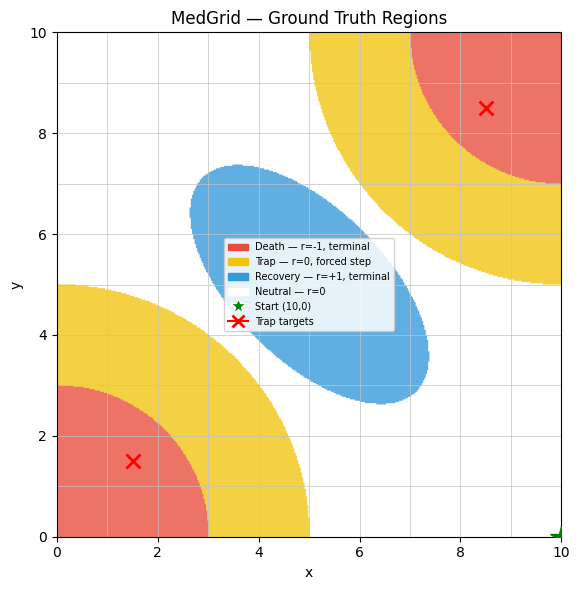

In [2]:
DEATH_R   = 3.0
TRAP_R    = 5.0
ELLIPSE_A = 3.0
ELLIPSE_B = 1.5


def classify_point(x, y):
    d_bl = np.sqrt(x**2 + y**2)
    d_tr = np.sqrt((x - 10)**2 + (y - 10)**2)
    if d_bl <= DEATH_R or d_tr <= DEATH_R:
        return 'death'
    if d_bl <= TRAP_R or d_tr <= TRAP_R:
        return 'trap'
    dx, dy = x - 5.0, y - 5.0
    if ((dx - dy)**2 / (2 * ELLIPSE_A**2) + (dx + dy)**2 / (2 * ELLIPSE_B**2)) <= 1.0:
        return 'recovery'
    return 'neutral'


def build_region_image(resolution=400):
    COLORS = {
        'death':    np.array([231,  76,  60, 200], dtype=np.uint8),
        'trap':     np.array([241, 196,  15, 200], dtype=np.uint8),
        'recovery': np.array([ 52, 152, 219, 200], dtype=np.uint8),
        'neutral':  np.array([255, 255, 255, 255], dtype=np.uint8),
    }
    xs = np.linspace(0, SIZE, resolution)
    ys = np.linspace(0, SIZE, resolution)
    img = np.zeros((resolution, resolution, 4), dtype=np.uint8)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            img[j, i] = COLORS[classify_point(x, y)]
    return img


def plot_ground_truth(ax=None, resolution=400):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure
    ax.imshow(build_region_image(resolution), origin='lower',
              extent=[0, SIZE, 0, SIZE], aspect='equal')
    for i in range(11):
        ax.axhline(i, color='#bdc3c7', lw=0.5, zorder=2)
        ax.axvline(i, color='#bdc3c7', lw=0.5, zorder=2)
    ax.plot(1.5, 1.5, 'rx', markersize=10, markeredgewidth=2, zorder=4)
    ax.plot(8.5, 8.5, 'rx', markersize=10, markeredgewidth=2, zorder=4)
    ax.plot(10, 0, 'g*', markersize=16, zorder=5)
    legend_patches = [
        mpatches.Patch(color='#e74c3c', label='Death — r=-1, terminal'),
        mpatches.Patch(color='#f1c40f', label='Trap — r=0, forced step'),
        mpatches.Patch(color='#3498db', label='Recovery — r=+1, terminal'),
        mpatches.Patch(color='white',   label='Neutral — r=0'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='g', markersize=12, label='Start (10,0)'),
        plt.Line2D([0],[0], marker='x', color='r', markersize=8, markeredgewidth=2, label='Trap targets'),
    ]
    ax.legend(handles=legend_patches, loc='center', fontsize=7,
              framealpha=0.85, bbox_to_anchor=(0.5, 0.5))
    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title('MedGrid — Ground Truth Regions')
    return fig, ax


print('Rasterising region map...')
fig, ax = plot_ground_truth()
plt.tight_layout()
plt.show()

## 2. Load discrete agents

Train first if needed:
```bash
cd toy_domain
../.venv/bin/python run.py -env MedGrid -action_mode discrete -n_bins 11 \
    -agent iqn -ded -frames 500000 -info medgrid_iqn_discrete
```

In [3]:
import io


class CpuUnpickler(pickle.Unpickler):
    """Unpickler that maps CUDA-backed torch storages onto CPU."""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(
                io.BytesIO(b), map_location=torch.device('cpu'), weights_only=False
            )
        return super().find_class(module, name)


def load_pickle_cpu(path):
    with open(path, 'rb') as f:
        return CpuUnpickler(f).load()


disc_agent, disc_qd, disc_qr = None, None, None
try:
    disc_agent = load_pickle_cpu(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_agent.pkl'))
    print('Loaded discrete main agent')
    disc_qd = load_pickle_cpu(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_Qd.pkl'))
    disc_qr = load_pickle_cpu(os.path.join(DISC_RUN_DIR, f'{DISC_RUN_NAME}_Qr.pkl'))
    print('Loaded discrete Qd and Qr networks')
except FileNotFoundError as e:
    print(f'Agents not found ({e}) — train first with the command above.')
except RuntimeError as e:
    print(f'Failed to load agents due to runtime error: {e}')

Loaded discrete main agent
Loaded discrete Qd and Qr networks


## 3. Discrete agent — CVaR Q-value heatmaps over action grid at state (10, 0)

The discrete IQN outputs quantiles for **all actions simultaneously**: `forward(state, n_tau) -> (1, n_tau, n_actions)`.  
We compute the lower CVaR at level η for each action, then reshape the `n_bins²` values back into the `(n_bins, n_bins)` spatial grid to visualise them in the 10×10 coordinate frame.

In [4]:
def _prepare_iqn_for_device(disc_ded_agent, device):
    network = disc_ded_agent.qnetwork_local
    network.to(device)
    network.device = device
    if hasattr(network, 'pis'):
        network.pis = network.pis.to(device)
    return network


def compute_discrete_action_heatmap(disc_ded_agent, state=FIXED_STATE,
                                     n_bins=N_BINS_DISC, n_tau=N_TAU, eta=ETA, device=DEVICE):
    """
    Compute CVaR Q-values for all n_bins^2 discrete actions at a fixed state.

    The discrete IQN forward pass returns (1, n_tau, n_actions), giving all
    action quantiles in one shot.

    Returns
    -------
    heatmap : (n_bins, n_bins) float32 — row=x bin, col=y bin
    bins    : 1-D array of grid coordinates (same for both axes)
    """
    n_keep = max(1, int(eta * n_tau))
    network = _prepare_iqn_for_device(disc_ded_agent, device)
    network.eval()

    s = torch.tensor([state], dtype=torch.float32).to(device)  # (1, 2)

    with torch.no_grad():
        quantiles, _ = network.forward(s, num_tau=n_tau)
        # quantiles: (1, n_tau, n_actions)

    q = quantiles.squeeze(0).cpu().numpy()     # (n_tau, n_actions)
    q_sorted = np.sort(q, axis=0)              # ascending along quantile axis
    cvar = q_sorted[:n_keep, :].mean(axis=0)   # (n_actions,)

    # action i encodes (bins[i//n_bins], bins[i%n_bins])
    heatmap = cvar.reshape(n_bins, n_bins)
    bins = np.linspace(0.0, SIZE, n_bins, dtype=np.float32)
    return heatmap, bins


def plot_discrete_action_heatmap(heatmap, bins, title, ax=None):
    """
    Plot the discrete CVaR heatmap in the 10x10 MedGrid coordinate frame.
    x-axis = action x target, y-axis = action y target.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    # heatmap[i,j] = CVaR for action (bins[i], bins[j])
    # transpose: rows->y, cols->x for imshow origin='lower'
    display = heatmap.T

    norm = TwoSlopeNorm(vmin=display.min(), vcenter=0, vmax=max(display.max(), 1e-6))
    im = ax.imshow(
        display,
        origin='lower',
        extent=[bins[0], bins[-1], bins[0], bins[-1]],
        cmap='RdBu',
        norm=norm,
        aspect='equal',
        interpolation='nearest',
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='CVaR Q')

    for b in bins:
        ax.axvline(b, color='k', lw=0.4, alpha=0.4)
        ax.axhline(b, color='k', lw=0.4, alpha=0.4)

    ax.set_xlim(0, SIZE); ax.set_ylim(0, SIZE)
    ax.set_xlabel('action x'); ax.set_ylabel('action y')
    ax.set_title(title)
    return fig, ax

### 3a. Q_d (danger network) — discrete action grid at state (10, 0)
Actions leading toward danger should be **red (≈ −1)**; safe actions **white/blue**.

Computing discrete Qd heatmap at state [10.0, 0.0]...
  range: [-1.009, 0.002]


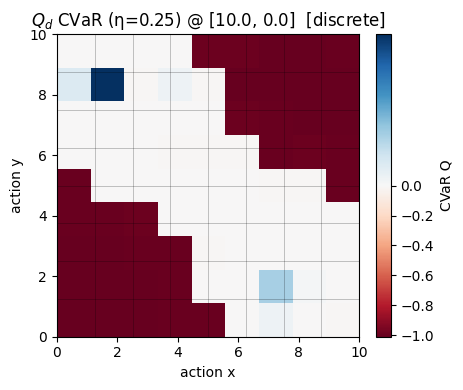

In [5]:
assert disc_qd is not None, 'disc_qd not loaded — train first with the command above'

print(f'Computing discrete Qd heatmap at state {FIXED_STATE}...')
disc_heatmap_d, disc_bins = compute_discrete_action_heatmap(disc_qd)
print(f'  range: [{disc_heatmap_d.min():.3f}, {disc_heatmap_d.max():.3f}]')

fig, ax = plot_discrete_action_heatmap(disc_heatmap_d, disc_bins,
                                        title=f'$Q_d$ CVaR (η={ETA}) @ {FIXED_STATE}  [discrete]')
plt.tight_layout()
plt.show()

### 3b. Q_r (recovery network) — discrete action grid at state (10, 0)
Actions leading toward recovery should be **blue (≈ +1)**; others **white/red**.

Computing discrete Qr heatmap at state [10.0, 0.0]...
  range: [-0.012, 0.996]


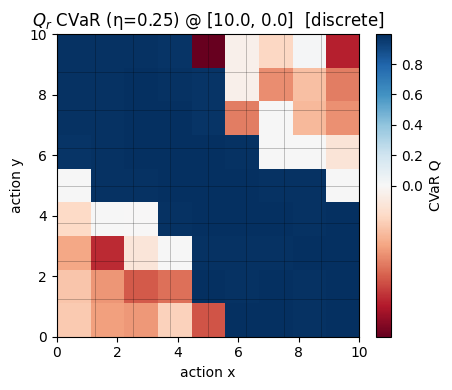

In [6]:
assert disc_qr is not None, 'disc_qr not loaded — train first with the command above'

print(f'Computing discrete Qr heatmap at state {FIXED_STATE}...')
disc_heatmap_r, _ = compute_discrete_action_heatmap(disc_qr)
print(f'  range: [{disc_heatmap_r.min():.3f}, {disc_heatmap_r.max():.3f}]')

fig, ax = plot_discrete_action_heatmap(disc_heatmap_r, disc_bins,
                                        title=f'$Q_r$ CVaR (η={ETA}) @ {FIXED_STATE}  [discrete]')
plt.tight_layout()
plt.show()

## 4. Side-by-side summary — discrete agent

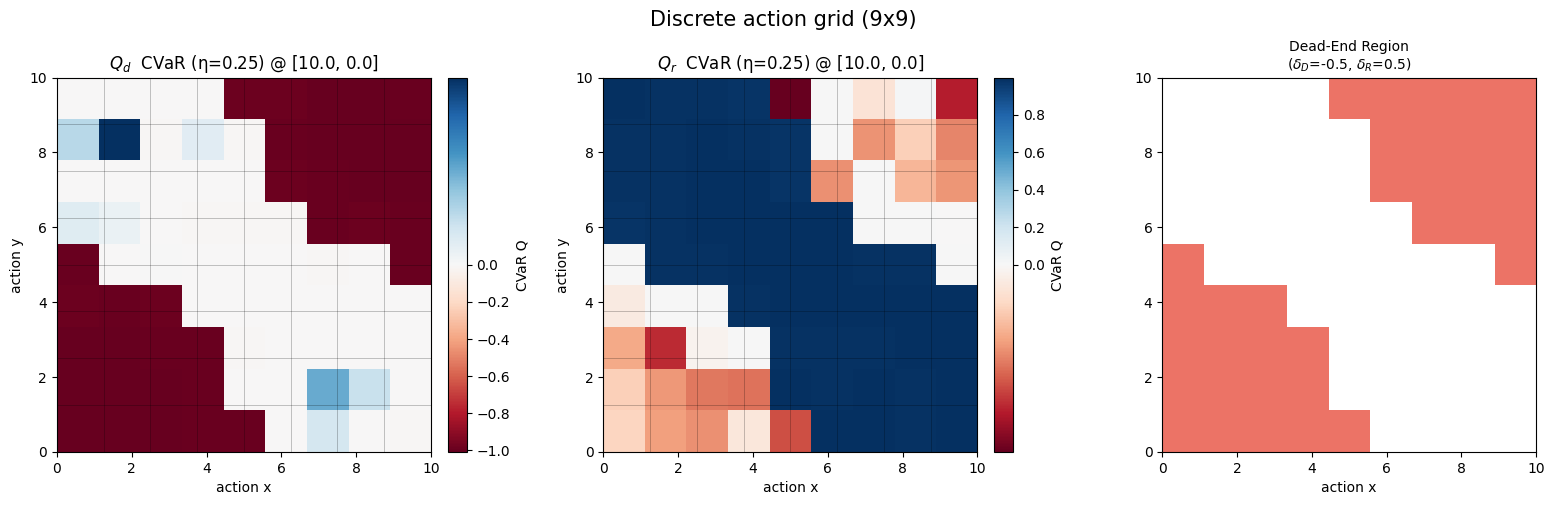

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_discrete_9bins_100kframes/medgrid_disc_ded_action_heatmaps.png


In [9]:
if disc_qd is not None and disc_qr is not None:
    disc_heatmap_d, disc_bins = compute_discrete_action_heatmap(disc_qd, state=FIXED_STATE)
    disc_heatmap_r, _ = compute_discrete_action_heatmap(disc_qr, state=FIXED_STATE)

    delta_d = -0.5
    delta_r = 0.5
    dead_end_grid = (disc_heatmap_d <= delta_d) & (disc_heatmap_r <= delta_r)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    dead_rgba = np.zeros((N_BINS_DISC, N_BINS_DISC, 4), dtype=np.uint8)
    dead_rgba[ dead_end_grid] = [231,  76,  60, 200]
    dead_rgba[~dead_end_grid] = [255, 255, 255, 220]
    axes[2].imshow(np.transpose(dead_rgba, (1, 0, 2)), origin='lower',
                   extent=[0, SIZE, 0, SIZE], interpolation='nearest', aspect='equal')
    axes[2].set_xlabel('action x'); axes[0].set_ylabel('action y')
    axes[2].set_title(
        f'Dead-End Region\n($\\delta_D$={delta_d}, $\\delta_R$={delta_r})', fontsize=10)

    plot_discrete_action_heatmap(disc_heatmap_d, disc_bins,
                                  title=f'$Q_d$  CVaR (η={ETA}) @ {FIXED_STATE}', ax=axes[0])
    plot_discrete_action_heatmap(disc_heatmap_r, disc_bins,
                                  title=f'$Q_r$  CVaR (η={ETA}) @ {FIXED_STATE}', ax=axes[1])

    fig.suptitle(
        f'Discrete action grid ({N_BINS_DISC}x{N_BINS_DISC})',
        fontsize=15)
    plt.tight_layout()
    out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_ded_action_heatmaps.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — no trained agents loaded.')

## 5. Sweep across states of interest

Evaluate the discrete CVaR heatmaps at multiple states to see how the Q-value landscape shifts depending on where the agent currently is.

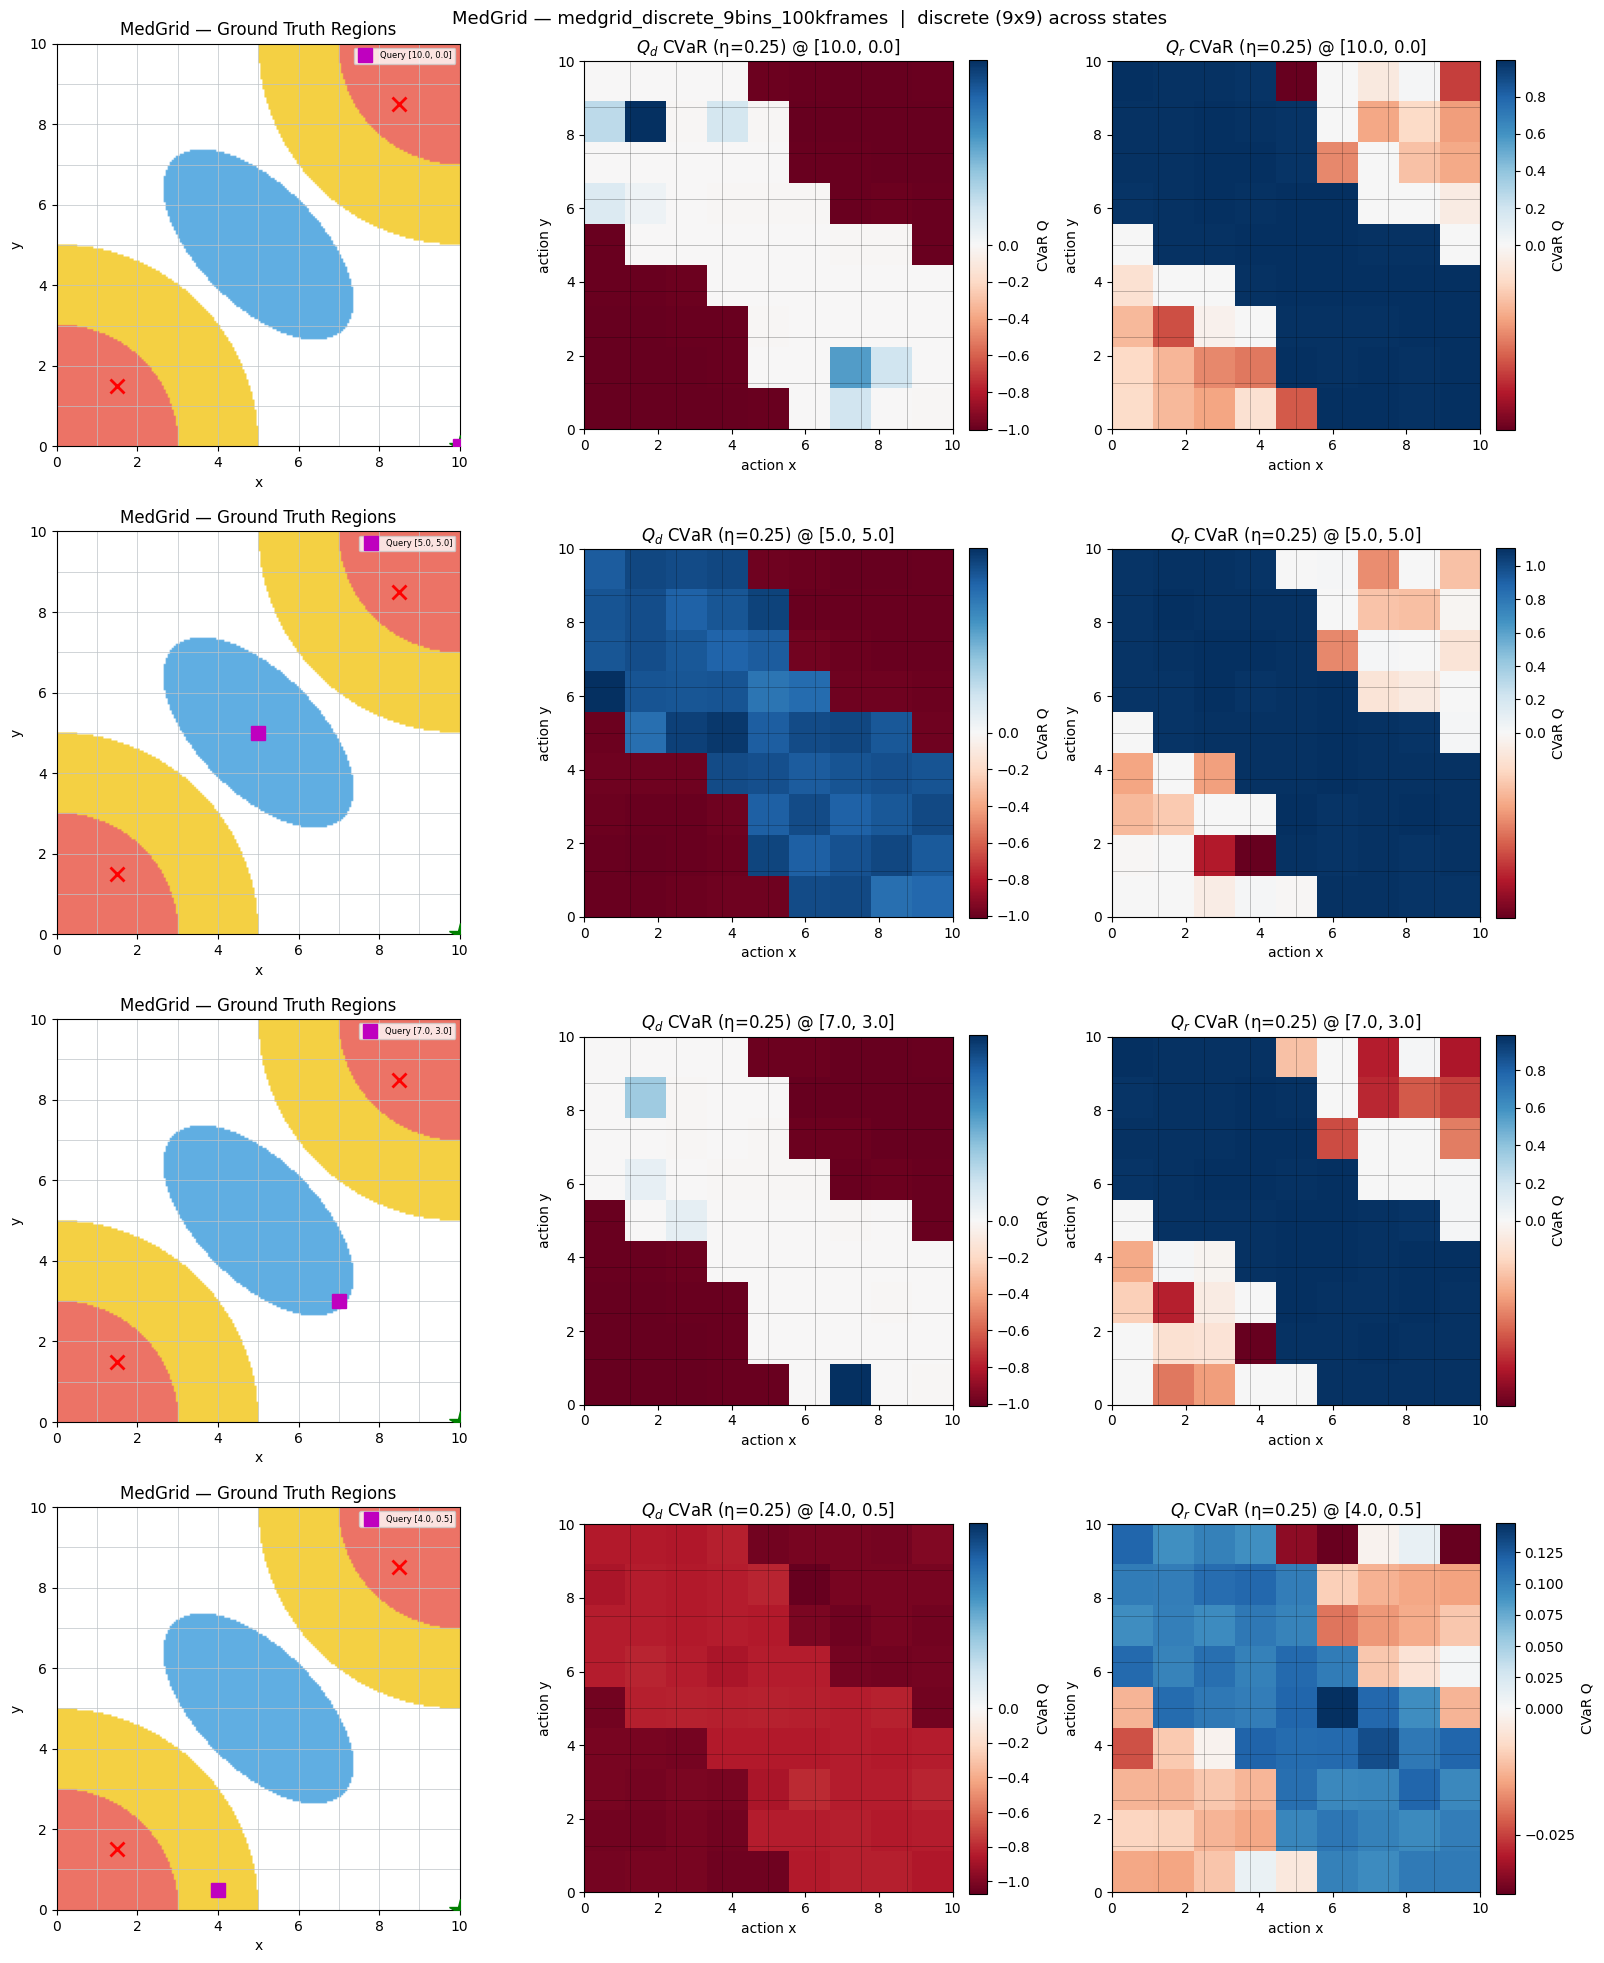

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_discrete_9bins_100kframes/medgrid_disc_ded_multi_state_heatmaps.png


In [25]:
EVAL_STATES = [
    [10.0,  0.0],   # start corner
    [ 5.0,  5.0],   # centre (recovery zone)
    [ 7.0,  3.0],   # neutral, mid-right
    [ 4.0,  0.5],   # inside BL trap band
]

if disc_qd is not None and disc_qr is not None:
    fig, axes = plt.subplots(len(EVAL_STATES), 3,
                             figsize=(16, 5 * len(EVAL_STATES)))

    for row, state in enumerate(EVAL_STATES):
        hm_d, bins = compute_discrete_action_heatmap(disc_qd, state=state)
        hm_r, _    = compute_discrete_action_heatmap(disc_qr, state=state)

        plot_ground_truth(ax=axes[row, 0], resolution=200)
        axes[row, 0].plot(state[0], state[1], 'ms', markersize=10, zorder=6,
                          label=f'Query {state}')
        axes[row, 0].legend(loc='upper right', fontsize=6)

        plot_discrete_action_heatmap(hm_d, bins,
                                      title=f'$Q_d$ CVaR (η={ETA}) @ {state}',
                                      ax=axes[row, 1])
        plot_discrete_action_heatmap(hm_r, bins,
                                      title=f'$Q_r$ CVaR (η={ETA}) @ {state}',
                                      ax=axes[row, 2])

    fig.suptitle(
        f'MedGrid — {DISC_RUN_NAME}  |  discrete ({N_BINS_DISC}x{N_BINS_DISC}) across states',
        fontsize=13)
    plt.tight_layout()
    out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_ded_multi_state_heatmaps.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to', out_path)
else:
    print('Skipped — no trained agents loaded.')

## 6. Fixed-State Action-Space Classification

Evaluate DistDeD on the discrete action grid at the fixed start state.

Each action bin is treated as a candidate target position.

**Prediction rule:** an action bin is predicted as a dead-end when both
$Q_d$ and $Q_r$ lower-CVaR values cross their thresholds:

$\mathrm{CVaR}(Q_d) \leq \delta_D$ and $\mathrm{CVaR}(Q_r) \leq \delta_R$

**Ground truth:** `classify_point(action_x, action_y)` returning `'death'` or `'trap'`.

In [26]:
DELTA_D = -0.5
DELTA_R =  0.5
N_CONT_ACTION_SAMPLES = 100000  # easy knob: number of continuous actions to sample
SAMPLE_SEED = 7


def nearest_discrete_indices(actions, action_bins):
    """Map continuous actions to nearest discrete (x_bin, y_bin) indices."""
    ix = np.abs(actions[:, 0][:, None] - action_bins[None, :]).argmin(axis=1)
    iy = np.abs(actions[:, 1][:, None] - action_bins[None, :]).argmin(axis=1)
    return ix, iy


def plot_confusion_matrix(cm, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3.5))
    else:
        fig = ax.figure

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    labels = ['Not Dead-End', 'Dead-End']
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_title('Confusion Matrix\n(Continuous sampled actions, discrete-policy lookup)', fontsize=10)

    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', fontsize=12,
                    color='white' if cm[i, j] > thresh else 'black')
    return fig, ax


assert disc_qd is not None and disc_qr is not None, 'Need loaded agents — run cell 2 first'

print(f'Sampling {N_CONT_ACTION_SAMPLES} continuous actions in [0, {SIZE}]^2 at state {FIXED_STATE} ...')
print(f'  δD = {DELTA_D},  δR = {DELTA_R},  η = {ETA},  seed = {SAMPLE_SEED}')

# Discrete model outputs over its full action grid.
cvar_d_action_grid, action_bins = compute_discrete_action_heatmap(disc_qd, state=FIXED_STATE)
cvar_r_action_grid, _ = compute_discrete_action_heatmap(disc_qr, state=FIXED_STATE)

# Keep these for downstream action-grid plot cell.
gt_action_grid = np.array(
    [[classify_point(x, y) in ('death', 'trap') for y in action_bins] for x in action_bins],
    dtype=bool,
)
pred_action_grid = (cvar_d_action_grid <= DELTA_D) & (cvar_r_action_grid <= DELTA_R)

# Sample continuous actions and compare to nearest-bin model prediction.
rng = np.random.default_rng(SAMPLE_SEED)
sampled_actions = rng.uniform(0.0, SIZE, size=(N_CONT_ACTION_SAMPLES, 2)).astype(np.float32)
ix, iy = nearest_discrete_indices(sampled_actions, action_bins)
pred_sample = (cvar_d_action_grid[ix, iy] <= DELTA_D) & (cvar_r_action_grid[ix, iy] <= DELTA_R)

gt_sample = np.array(
    [classify_point(a[0], a[1]) in ('death', 'trap') for a in sampled_actions],
    dtype=bool,
)

TP = int(( gt_sample &  pred_sample).sum())
TN = int((~gt_sample & ~pred_sample).sum())
FP = int((~gt_sample &  pred_sample).sum())
FN = int(( gt_sample & ~pred_sample).sum())
cm_action = np.array([[TN, FP], [FN, TP]])

print(f'\nTP={TP}  TN={TN}  FP={FP}  FN={FN}')

Sampling 100000 continuous actions in [0, 10.0]^2 at state [10.0, 0.0] ...
  δD = -0.5,  δR = 0.5,  η = 0.25,  seed = 7

TP=36180  TN=58423  FP=2185  FN=3212


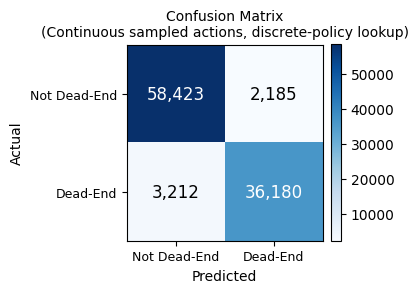

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_discrete_9bins_100kframes/medgrid_disc_confusion_matrix.png


In [27]:
fig, ax = plt.subplots(figsize=(4, 3.5))
plot_confusion_matrix(cm_action, ax=ax)
plt.tight_layout()
out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_confusion_matrix.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', out_path)

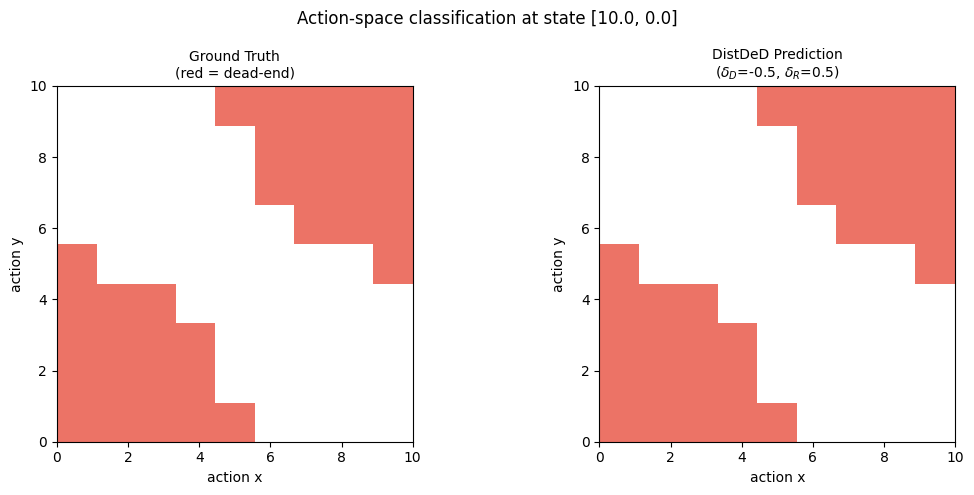

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_discrete_9bins_100kframes/medgrid_disc_action_grid.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

gt_rgba = np.zeros((*gt_action_grid.shape, 4), dtype=np.uint8)
gt_rgba[ gt_action_grid] = [231,  76,  60, 200]
gt_rgba[~gt_action_grid] = [255, 255, 255, 220]
axes[0].imshow(np.transpose(gt_rgba, (1, 0, 2)), origin='lower',
               extent=[0, SIZE, 0, SIZE], interpolation='nearest', aspect='equal')
axes[0].set_title('Ground Truth\n(red = dead-end)', fontsize=10)
axes[0].set_xlabel('action x'); axes[0].set_ylabel('action y')

pred_rgba = np.zeros((*pred_action_grid.shape, 4), dtype=np.uint8)
pred_rgba[ pred_action_grid] = [231,  76,  60, 200]
pred_rgba[~pred_action_grid] = [255, 255, 255, 220]
axes[1].imshow(np.transpose(pred_rgba, (1, 0, 2)), origin='lower',
               extent=[0, SIZE, 0, SIZE], interpolation='nearest', aspect='equal')
axes[1].set_title(
    f'DistDeD Prediction\n($\\delta_D$={DELTA_D}, $\\delta_R$={DELTA_R})', fontsize=10)
axes[1].set_xlabel('action x'); axes[1].set_ylabel('action y')

fig.suptitle(f'Action-space classification at state {FIXED_STATE}', fontsize=12)
plt.tight_layout()
out_path = os.path.join(DISC_RUN_DIR, 'medgrid_disc_action_grid.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', out_path)

## 7. Classification Metrics — Sampled Actions

Precision, recall, and F1 are computed from the sampled continuous-action evaluation above.
Boundary IoU is computed on the discrete action-grid masks used by the policy lookup.

Classification Metrics at state [10.0, 0.0]
  Precision / Recall / F1 use the sampled continuous actions.
  Boundary IoU uses 200×200 rasterisation (nearest-bin lookup).
  Precision    : 0.9430
  Recall       : 0.9185
  F1 Score     : 0.9306
  Boundary IoU : 0.0227


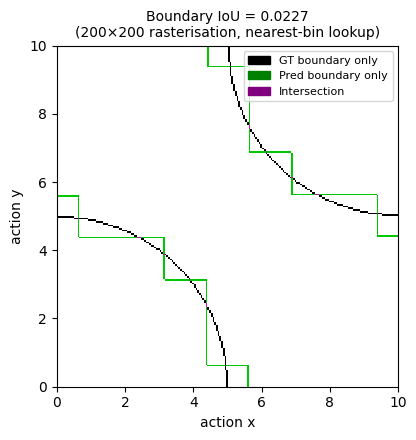

Saved to /home/jay/Uni/SafetyResearch/runs/medgrid_discrete_9bins_100kframes/metrics_boundary_iou_discrete.png


In [29]:
def boundary_mask(binary_grid):
    """Return boundary pixels using 4-neighbour connectivity on a boolean grid."""
    g = binary_grid.astype(np.int8)
    shifted = (
        np.pad(g, ((1, 0), (0, 0)), mode='edge')[:-1, :]
        + np.pad(g, ((0, 1), (0, 0)), mode='edge')[1:, :]
        + np.pad(g, ((0, 0), (1, 0)), mode='edge')[:, :-1]
        + np.pad(g, ((0, 0), (0, 1)), mode='edge')[:, 1:]
    )
    return binary_grid & (shifted < 4)


def boundary_iou(gt_grid, pred_grid):
    gt_boundary = boundary_mask(gt_grid)
    pred_boundary = boundary_mask(pred_grid)
    intersection = (gt_boundary & pred_boundary).sum()
    union = (gt_boundary | pred_boundary).sum()
    return float(intersection) / float(union) if union > 0 else float('nan')


precision = TP / (TP + FP) if (TP + FP) > 0 else float('nan')
recall = TP / (TP + FN) if (TP + FN) > 0 else float('nan')
f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else float('nan')
)

# ── Boundary IoU on a high-resolution rasterisation ─────────────────────────
# The coarse action grid (N_BINS × N_BINS = 9×9) has too few boundary pixels
# to give a meaningful IoU. Instead we rasterise both GT and predicted regions
# at BIOU_RES × BIOU_RES using nearest-bin lookup for the prediction.
BIOU_RES = 200
xs_biou = np.linspace(0, SIZE, BIOU_RES, dtype=np.float32)
ys_biou = np.linspace(0, SIZE, BIOU_RES, dtype=np.float32)

# GT: gt_hires[i, j] = classify(xs[i], ys[j])
gt_hires = np.array(
    [[classify_point(x, y) in ('death', 'trap') for y in ys_biou]
     for x in xs_biou],
    dtype=bool,
)

# Pred: nearest-bin lookup; ix_h[i] = closest bin index for xs[i]
ix_h = np.abs(xs_biou[:, None] - action_bins[None, :]).argmin(axis=1)
iy_h = np.abs(ys_biou[:, None] - action_bins[None, :]).argmin(axis=1)
pred_hires = pred_action_grid[np.ix_(ix_h, iy_h)]  # (BIOU_RES, BIOU_RES)

biou = boundary_iou(gt_hires, pred_hires)

print('=' * 60)
print(f'Classification Metrics at state {FIXED_STATE}')
print('  Precision / Recall / F1 use the sampled continuous actions.')
print(f'  Boundary IoU uses {BIOU_RES}×{BIOU_RES} rasterisation (nearest-bin lookup).')
print(f'  Precision    : {precision:.4f}')
print(f'  Recall       : {recall:.4f}')
print(f'  F1 Score     : {f1:.4f}')
print(f'  Boundary IoU : {biou:.4f}')
print('=' * 60)

# ── Boundary visualisation ────────────────────────────────────────────────────
gt_b   = boundary_mask(gt_hires)
pred_b = boundary_mask(pred_hires)
overlap = gt_b & pred_b

# gt_hires[i, j] → (xs[i], ys[j]); need np.transpose for imshow (origin='lower')
bnd_img = np.zeros((*gt_b.shape, 3), dtype=np.uint8) + 255
bnd_img[gt_b   & ~overlap] = [0,   0,   0]
bnd_img[pred_b & ~overlap] = [0,   200, 0]
bnd_img[overlap]            = [200, 0,   200]

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.imshow(
    np.transpose(bnd_img, (1, 0, 2)),
    origin='lower',
    extent=[0, SIZE, 0, SIZE],
    interpolation='nearest',
    aspect='equal',
)
legend_patches = [
    mpatches.Patch(color='black',  label='GT boundary only'),
    mpatches.Patch(color='green',  label='Pred boundary only'),
    mpatches.Patch(color='purple', label='Intersection'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='upper right')
ax.set_xlabel('action x')
ax.set_ylabel('action y')
ax.set_title(f'Boundary IoU = {biou:.4f}\n({BIOU_RES}×{BIOU_RES} rasterisation, nearest-bin lookup)', fontsize=10)
plt.tight_layout()
out_path = os.path.join(DISC_RUN_DIR, 'metrics_boundary_iou_discrete.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved to', out_path)
